# **1.0 INTRODUCTION:**

This Capstone project is based on detecting credit fraud to help financial intituitions protect their customers finances efficiently. In recent years, credit card fraud has increased significantly due to the rapid growth of digital payments and online transactions (Nilson Report, 2022; UK Finance, 2023). Fraudulent activities not only cause substantial financial losses to banks but also damage customer trust and brand reputation(PwC, 2022).
Financial institutions aim to retain profitable customers and ensure secure transactions. However, fraudsters use various techniques such as card skimming, phishing, account takeover, and data breaches to gain unauthorized access to cardholder information (Federal Trade Commission, 2023).
In many cases, fraudulent transactions are detected late, leading to high revenue losses as banks must reimburse affected customers (UK Finance, 2023).

Fraud transactions typically represent a very small percentage of total transactions (often less than 0.05%), making detection extremely challenging (Dal Pozzolo et al., 2015). This class imbalance problem, combined with evolving fraud techniques, makes traditional rule-based systems insufficient.



### **1.1 PROBLEM STATEMENT & BUISNESS CONTEXT:**

Finex, a financial services provider, has observed a significant rise in unauthorized transactions, resulting in financial losses and customer dissatisfaction. The bank currently lacks advanced real-time fraud detection capabilities, highlighting the need for a data-driven solution.

### **1.2 OBJECTIVE & APPROACH:**

To address this issue, this project aims to build a machine learning-based fraud detection system that can:

1. Identify suspicious transactions in real time

2. Minimize financial losses

3. Reduce false alarms

4. Improve customer trust

This project simulates a real-world fraud detection system for a financial institution using a publicly available transaction dataset. By leveraging supervised machine learning techniques such as Logistic Regression, Decision Trees, and other classification models, this project seeks to develop an effective and scalable fraud detection solution while handling challenges such as class imbalance and model interpretability.

# **2.0 DATA UNDERSTANDING**

### **2.1 ABOUT THE DATASET:**

The dataset used in this project was obtained from Kaggle (Credit Card Transactions Fraud Detection Dataset). It is a synthetically generated credit card transaction dataset created using the Sparkov data generation tool developed by Brandon Harris. The dataset simulates transactions over the period January 2019 to December 2020 and includes activity from 1,000 customers interacting with approximately 800 merchants across multiple transaction categories.

As the dataset is synthetically generated, it reflects simulated fraud patterns rather than real-world adversarial behavior. Therefore, the model performance in this project demonstrates the effectiveness of the fraud detection framework under controlled conditions. While this allows rigorous experimentation, class imbalance handling, and evaluation strategy development, results should be interpreted as proof of modeling capability rather than direct real-world deployment readiness.


### **2.2 LOADING DATA & INITIAL INSPECTION:**

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Load datasets from Drive
fraud_train_df = pd.read_csv("/content/drive/MyDrive/credit_fraud_detection_data/fraudTrain.csv")
fraud_test_df  = pd.read_csv("/content/drive/MyDrive/credit_fraud_detection_data/fraudTest.csv")

# Quick check
print(f"Train shape: {fraud_train_df.shape}")
print(f"Test shape : {fraud_test_df.shape}")

fraud_train_df.head()

Mounted at /content/drive
Train shape: (1296675, 23)
Test shape : (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
# Column overview
column_summary = pd.DataFrame({
    "column": fraud_train_df.columns,
    "dtype": fraud_train_df.dtypes.values,
    "non_null_count": fraud_train_df.notnull().sum().values
})

column_summary

,column,dtype,non_null_count
0,Unnamed: 0,int64,1296675
1,trans_date_trans_time,object,1296675
2,cc_num,int64,1296675
3,merchant,object,1296675
4,category,object,1296675
5,amt,float64,1296675
6,first,object,1296675
7,last,object,1296675
8,gender,object,1296675
9,street,object,1296675


In [ ]:
# Sample values to understand column meaning
fraud_train_df.head(3).T

,0,1,2
Unnamed: 0,0,1,2
trans_date_trans_time,2019-01-01 00:00:18,2019-01-01 00:00:44,2019-01-01 00:00:51
cc_num,2703186189652095,630423337322,38859492057661
merchant,"fraud_Rippin, Kub and Mann","fraud_Heller, Gutmann and Zieme",fraud_Lind-Buckridge
category,misc_net,grocery_pos,entertainment
amt,4.97,107.23,220.11
first,Jennifer,Stephanie,Edward
last,Banks,Gill,Sanchez
gender,F,F,M
street,561 Perry Cove,43039 Riley Greens Suite 393,594 White Dale Suite 530


**INFERENCE:**

The dataset contains approximately 1.29 million transactions across 24 columns. Each row represents an individual credit card transaction, including transaction-level details (timestamp and amount), merchant information, customer attributes, and a binary fraud indicator.

The target variable, is_fraud, denotes whether a transaction is fraudulent (1) or legitimate (0). The dataset includes a combination of numerical and categorical features, reflecting diverse transaction, customer, and merchant characteristics.

Initial inspection confirms that the data is structured at the transaction level, making it suitable for supervised binary classification analysis.

### **2.3 DATA QUALITY CHECKS:**

In [ ]:
# Columns to drop (no predictive value / identifiers / personal info)
columns_to_drop = [
    "Unnamed: 0",
    "trans_num",
    "first",
    "last",
    "street"

]

# Drop columns
fraud_train_df = fraud_train_df.drop(columns=columns_to_drop)
fraud_test_df  = fraud_test_df.drop(columns=columns_to_drop)

# Verify
print("Remaining columns train data:", fraud_train_df.columns.tolist())
print("Remaining columns in test data:", fraud_test_df.columns.tolist())


Remaining columns train data: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
Remaining columns in test data: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [ ]:
import numpy as np

def engineer_features(df):
    df = df.copy()

    # --- Datetime features ---
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["day"] = df["trans_date_trans_time"].dt.day
    df["dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # --- Age feature from DOB ---
    df["dob"] = pd.to_datetime(df["dob"])
    df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days // 365

    # --- Distance between customer & merchant (Haversine) ---
    def haversine(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        return 6371 * 2 * np.arcsin(np.sqrt(a))  # distance in km

    df["distance_km"] = haversine(
        df["lat"], df["long"], df["merch_lat"], df["merch_long"]
    )

    # --- Drop raw columns no longer needed ---
    df = df.drop(columns=[
        "trans_date_trans_time",
        "dob",
        "unix_time"
    ])

    return df


# Apply to train and test
fraud_train_df = engineer_features(fraud_train_df)
fraud_test_df  = engineer_features(fraud_test_df)

# Quick check
fraud_train_df.head()

,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,...,job,merch_lat,merch_long,is_fraud,hour,day,dayofweek,is_weekend,age,distance_km
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,...,"Psychologist, counselling",36.011293,-82.048315,0,0,1,1,0,30,78.597568
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,...,Special educational needs teacher,49.159047,-118.186462,0,0,1,1,0,40,30.212176
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,...,Nature conservation officer,43.150704,-112.154481,0,0,1,1,0,56,108.206083
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,...,Patent attorney,47.034331,-112.561071,0,0,1,1,0,52,95.673231
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,...,Dance movement psychotherapist,38.674999,-78.632459,0,0,1,1,0,32,77.556744


In [ ]:
# Missing values check
missing_values = fraud_train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Missing values (train):")
print(missing_values if not missing_values.empty else "No missing values found.")

# Duplicate rows check
duplicate_count = fraud_train_df.duplicated().sum()
print(f"\nDuplicate rows (train): {duplicate_count}")

Missing values (train):
No missing values found.

Duplicate rows (train): 0


The dataset was checked for missing values and duplicate transactions. No missing values or duplicates were found, allowing to proceed without additional data cleaning or imputation steps.

In [ ]:
# Data types overview
fraud_train_df.dtypes


,0
cc_num,int64
merchant,object
category,object
amt,float64
gender,object
city,object
state,object
zip,int64
lat,float64
long,float64


In [ ]:
# Drop credit card number (identifier, not a feature)
fraud_train_df = fraud_train_df.drop(columns=["cc_num"])
fraud_test_df  = fraud_test_df.drop(columns=["cc_num"])

# Verify
print("cc_num dropped successfully.")

cc_num dropped successfully.


Initially the card identifier column (cc_num) was retained to evaluate whether per-card aggregation features were needed. For the baseline model, it is excluded to avoid leakage and complexity as the goal is to primarily analyse the patterns of transactions that are potentially fradulent.

In [ ]:

# Class distribution
class_counts = fraud_train_df["is_fraud"].value_counts()
class_percent = fraud_train_df["is_fraud"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass distribution (%):")
print(class_percent.round(2))

Class counts:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Class distribution (%):
is_fraud
0    99.42
1     0.58
Name: proportion, dtype: float64


The dataset exhibits severe class imbalance, with fraudulent transactions representing only 0.58% of the total.

In [ ]:
# Negative transaction amounts
neg_amt_count = (fraud_train_df['amt'] < 0).sum()
print("Negative transaction amounts:", neg_amt_count)

# Basic statistics
print("\nTransaction Amount Summary:")
print(fraud_train_df['amt'].describe())

Negative transaction amounts: 0

Transaction Amount Summary:
count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64


In [ ]:
# Age range check
print("Minimum age:", fraud_train_df['age'].min())
print("Maximum age:", fraud_train_df['age'].max())

# Unrealistic ages
invalid_age_count = ((fraud_train_df['age'] < 0) | (fraud_train_df['age'] > 100)).sum()
print("Unrealistic age count:", invalid_age_count)

Minimum age: 13
Maximum age: 95
Unrealistic age count: 0


In [ ]:
# ZIP basic check
print("Minimum ZIP:", fraud_train_df['zip'].min())
print("Maximum ZIP:", fraud_train_df['zip'].max())

# Negative ZIPs
neg_zip_count = (fraud_train_df['zip'] < 0).sum()
print("Negative ZIP codes:", neg_zip_count)

Minimum ZIP: 1257
Maximum ZIP: 99783
Negative ZIP codes: 0


In [ ]:
# Distance check
neg_distance_count = (fraud_train_df['distance_km'] < 0).sum()
print("Negative distance values:", neg_distance_count)

print("\nDistance Summary:")
print(fraud_train_df['distance_km'].describe())

Negative distance values: 0

Distance Summary:
count    1.296675e+06
mean     7.611465e+01
std      2.911693e+01
min      2.225452e-02
25%      5.533491e+01
50%      7.823175e+01
75%      9.850327e+01
max      1.521172e+02
Name: distance_km, dtype: float64


In [ ]:
invalid_lat = ((fraud_train_df['lat'] < -90) | (fraud_train_df['lat'] > 90)).sum()
invalid_merch_lat = ((fraud_train_df['merch_lat'] < -90) | (fraud_train_df['merch_lat'] > 90)).sum()

# Longitude validity
invalid_long = ((fraud_train_df['long'] < -180) | (fraud_train_df['long'] > 180)).sum()
invalid_merch_long = ((fraud_train_df['merch_long'] < -180) | (fraud_train_df['merch_long'] > 180)).sum()

print("Invalid customer latitude:", invalid_lat)
print("Invalid merchant latitude:", invalid_merch_lat)
print("Invalid customer longitude:", invalid_long)
print("Invalid merchant longitude:", invalid_merch_long)

Invalid customer latitude: 0
Invalid merchant latitude: 0
Invalid customer longitude: 0
Invalid merchant longitude: 0


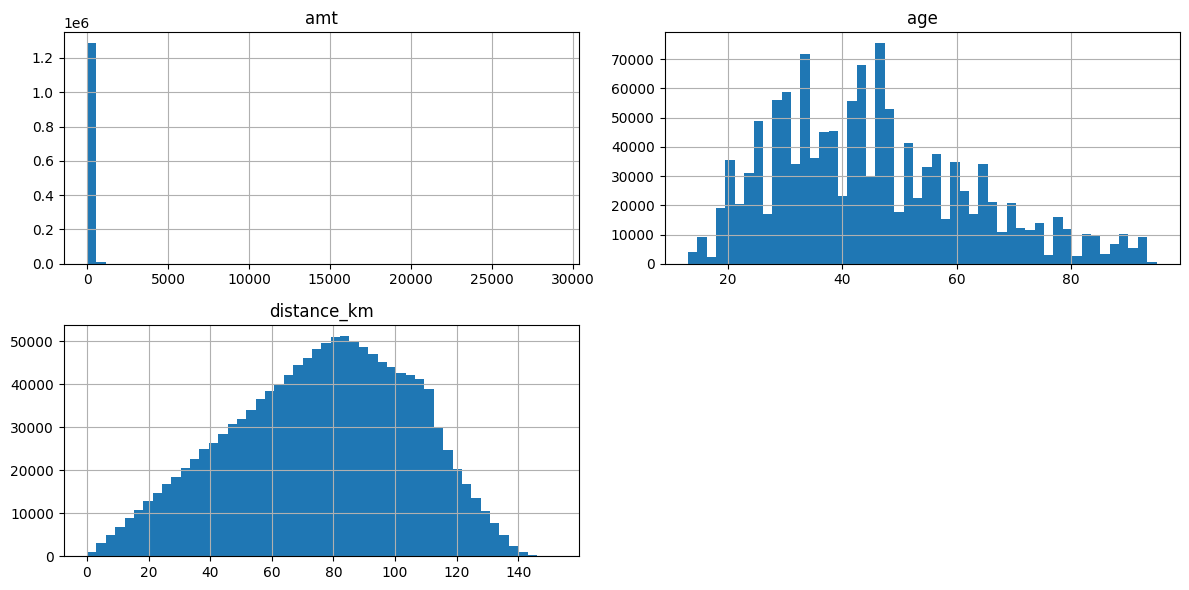

In [ ]:
# Overall distribuition:

import matplotlib.pyplot as plt

fraud_train_df[['amt', 'age', 'distance_km']].hist(bins=50, figsize=(12,6))
plt.tight_layout()
plt.show()

Range validation checks indicate no logically inconsistent values (such as negative amounts, invalid ages, or geographic coordinates). The dataset appears structurally coherent for modeling purposes.

**INFERENCE:**

After removing non-informative identifiers and engineering relevant temporal and spatial features, the dataset was assessed for structural quality. No missing values, duplicates, or logically inconsistent entries were observed. The data is therefore suitable for modeling. However, the fraud rate of 0.58% highlights a severe class imbalance, requiring specialized evaluation metrics and imbalance mitigation strategies during model development.

### **2.4 EXPLORATORY DATA ANALYSIS:**

In [ ]:
# check skewness of numeric variables

numeric_cols = fraud_train_df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("is_fraud")

# Compute skewness
skewness = fraud_train_df[numeric_cols].skew().sort_values(ascending=False)

print("Skewness of numeric features:")
print(skewness)

Skewness of numeric features:
amt            42.277874
city_pop        5.593853
is_weekend      0.637160
age             0.610871
zip             0.079681
merch_lat      -0.181915
lat            -0.186028
distance_km    -0.236208
merch_long     -1.146960
long           -1.150108
dtype: float64


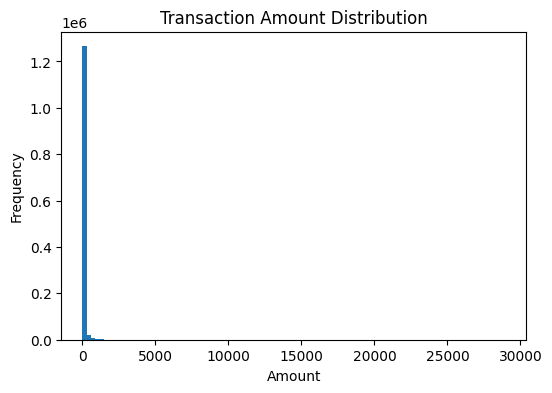

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(fraud_train_df["amt"], bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

From the above analysis and the histogram, extreme right skew in transaction amount (skewness > 40) is observed with a small number of high-value transactions.

In [ ]:
# Identify Outliers

numeric_cols = fraud_train_df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("is_fraud")

outlier_report = []

for col in numeric_cols:
    q1 = fraud_train_df[col].quantile(0.25)
    q3 = fraud_train_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((fraud_train_df[col] < lower) | (fraud_train_df[col] > upper)).sum()
    outlier_report.append((col, outliers))

outlier_df = pd.DataFrame(outlier_report, columns=["feature", "outlier_count"])
outlier_df.sort_values(by="outlier_count", ascending=False)

,feature,outlier_count
4,city_pop,242674
0,amt,67290
3,long,49922
6,merch_long,41994
5,merch_lat,4967
2,lat,4679
8,age,256
1,zip,0
7,is_weekend,0
9,distance_km,0


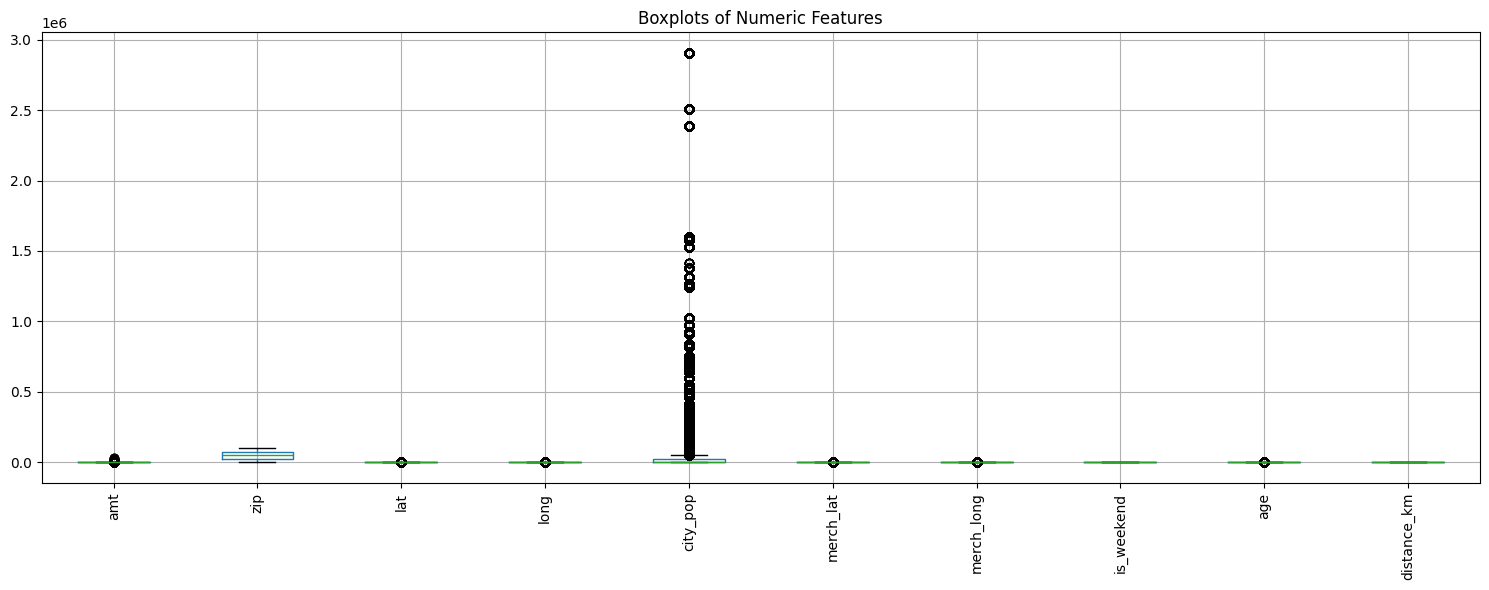

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = fraud_train_df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("is_fraud")

plt.figure(figsize=(15, 6))
fraud_train_df[numeric_cols].boxplot(rot=90)
plt.title("Boxplots of Numeric Features")
plt.tight_layout()
plt.show()

Exploratory analysis revealed extreme right skew in transaction amount (skewness > 40), driven by a small number of high-value transactions. These represent legitimate events rather than data errors. Instead of removing outliers, a log transformation is to be applied to transaction amount to reduce scale dominance while preserving fraud signal.

In [ ]:
# Log-transform transaction amount
fraud_train_df["log_amt"] = np.log1p(fraud_train_df["amt"])
fraud_test_df["log_amt"]  = np.log1p(fraud_test_df["amt"])

# Quick sanity check
print(
    "Original amt skew:",
    fraud_train_df["amt"].skew().round(2)
)
print(
    "Log-transformed amt skew:",
    fraud_train_df["log_amt"].skew().round(2)
)

Original amt skew: 42.28
Log-transformed amt skew: -0.3


After the log transformations, the skewness is reduced to near 0 while preserving the relative order of transactions.



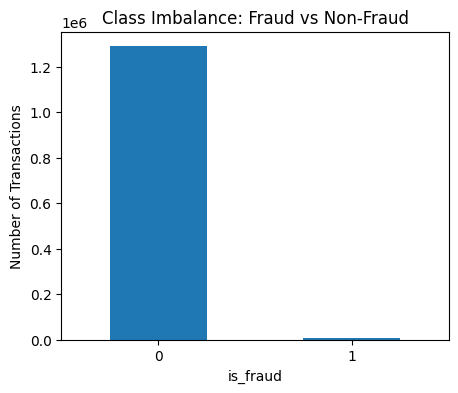

In [ ]:
# class imbalance plot

plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar")
plt.title("Class Imbalance: Fraud vs Non-Fraud")
plt.xlabel("is_fraud")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

From the above plot between fraudulent and non fraudulent cases, the count is highly imbalanced. Due to this, accuracy alone could not be relied as a metric for this project and PR-AUC and recall would be critical metrics to evaluate the modelling results

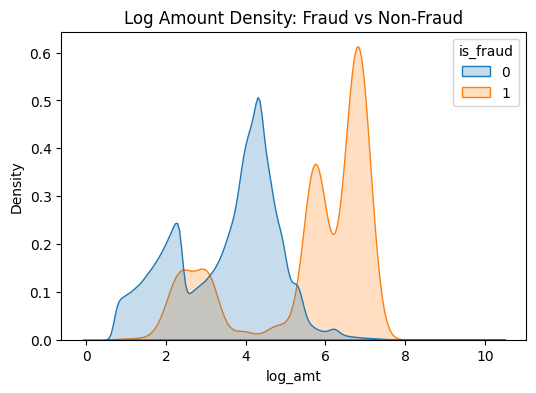

In [ ]:
# amount distribuition (fraud vs non-fraud)

import seaborn as sns

plt.figure(figsize=(6,4))

sns.kdeplot(
    data=fraud_train_df,
    x="log_amt",
    hue="is_fraud",
    common_norm=False,
    fill=True
)

plt.title("Log Amount Density: Fraud vs Non-Fraud")
plt.show()


The log-transformed transaction amount shows moderate separation between fraud and non-fraud transactions. Fraudulent transactions tend to occur at higher transaction amounts, although there remains substantial overlap between the two classes. This indicates that while transaction amount is a useful predictive feature, it is insufficient as a standalone discriminator.

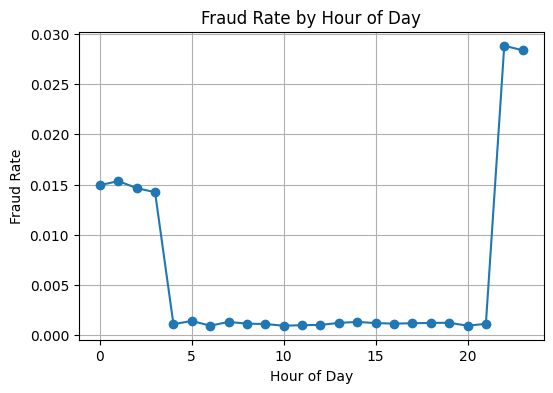

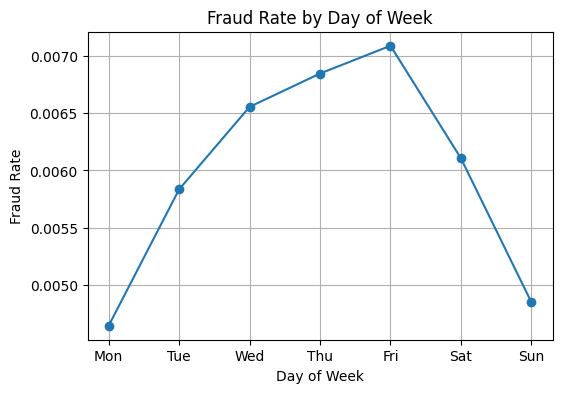

In [ ]:
# Time trend analysis

# Fraud rate by hour
fraud_by_hour = (
    fraud_train_df
    .groupby("hour")["is_fraud"]
    .mean()
)

plt.figure(figsize=(6, 4))
fraud_by_hour.plot(marker="o")
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.grid(True)
plt.show()

# Fraud rate by day of week
fraud_by_day = (
    fraud_train_df
    .groupby("dayofweek")["is_fraud"]
    .mean()
)


day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(6, 4))
plt.plot(day_labels, fraud_by_day.values, marker="o")
plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate")
plt.grid(True)
plt.show()


Temporal analysis reveals pronounced fraud patterns. Fraud rates are significantly higher during late-night hours and peak during late evening periods, likely reflecting reduced oversight and opportunistic behavior.

At a weekly level, fraud rates increase steadily from Monday to Friday and decline on weekends, suggesting alignment with business activity cycles. These findings justify the inclusion of hour-of-day and day-of-week features as key predictors in the fraud detection model.

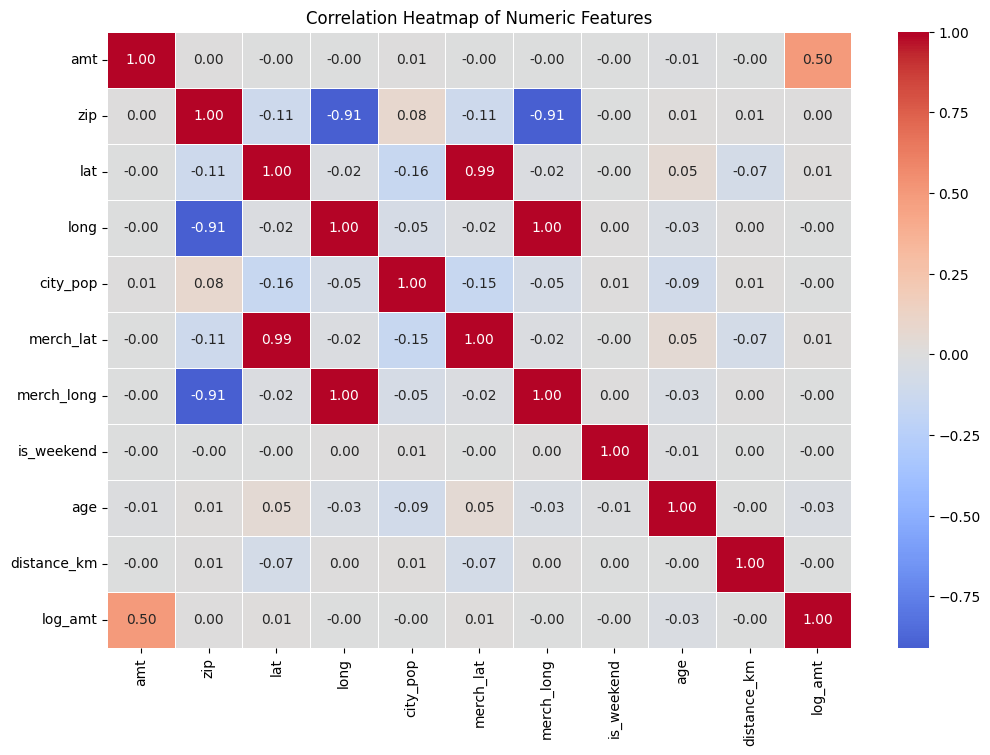

Correlation with target (is_fraud):


,is_fraud
amt,0.219404
log_amt,0.120439
age,0.012244
city_pop,0.002136
lat,0.001894
merch_lat,0.001741
merch_long,0.001721
long,0.001721
distance_km,0.000403
zip,-0.002162


In [ ]:
# Feature correlation

import seaborn as sns

# Select numeric features only (excluding target)
numeric_cols = fraud_train_df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("is_fraud")

# Correlation matrix
corr_matrix = fraud_train_df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Correlation with target
fraud_corr = fraud_train_df[numeric_cols.tolist() + ["is_fraud"]].corr()["is_fraud"]
fraud_corr = fraud_corr.drop("is_fraud").sort_values(ascending=False)

print("Correlation with target (is_fraud):")
fraud_corr

Correlation analysis revealed strong redundancy between customer and merchant geographic coordinates, motivating the use of distance-based features instead of raw latitude and longitude. Transaction amount showed the strongest linear association with fraud, while most other features exhibited low linear correlation, reflecting the non-linear and interaction-driven nature of fraud behavior.

In [ ]:
# Drop ZIP code (numeric but categorical, causes spurious correlations)
fraud_train_df = fraud_train_df.drop(columns=["zip"])
fraud_test_df  = fraud_test_df.drop(columns=["zip"])

print("zip column dropped successfully.")

zip column dropped successfully.


**INFERENCE:**

Exploratory analysis indicates that no individual feature provides a clear linear separation between fraudulent and legitimate transactions. Instead, fraud demonstrates partial differentiation across transaction amount and temporal patterns, with higher concentration observed in larger transaction values and late-night hours. However, substantial distributional overlap persists across most variables, suggesting that fraudulent behavior cannot be captured through simple threshold rules or univariate analysis.

The severe class imbalance (≈0.58% fraud rate) further highlights the complexity of the detection task and reinforces the need for imbalance-aware evaluation metrics. Additionally, high skewness in transaction amount required transformation to stabilize feature distributions, while correlation analysis confirmed the absence of a dominant single predictor and revealed limited linear association with the target variable.

Overall, the EDA suggests that fraud patterns are multivariate and interaction-driven rather than cluster-based, justifying the use of supervised machine learning models capable of capturing nonlinear relationships and feature interactions.

#**3.0 DATA PRE-PROCESSING**

###**3.1 TRAIN VALIDATION SPLIT**

In [ ]:
# stratified split to preserve fraud ratio
from sklearn.model_selection import train_test_split

# Separate features and target
X = fraud_train_df.drop(columns=["is_fraud"])
y = fraud_train_df["is_fraud"]

# Stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check fraud rate consistency
print("Original fraud rate:", y.mean().round(4))
print("Train fraud rate   :", y_train.mean().round(4))
print("Validation fraud rate:", y_val.mean().round(4))

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Original fraud rate: 0.0058
Train fraud rate   : 0.0058
Validation fraud rate: 0.0058
Train shape: (1037340, 19)
Validation shape: (259335, 19)


The training data set was split into training and validation data using stratified split to ensure that the split has equal proportion of the fraud cases to avoid biased predictions due to class imbalance.

In [ ]:
X_train.dtypes

,0
merchant,object
category,object
amt,float64
gender,object
city,object
state,object
lat,float64
long,float64
city_pop,int64
job,object


In [ ]:
X_val.dtypes

,0
merchant,object
category,object
amt,float64
gender,object
city,object
state,object
lat,float64
long,float64
city_pop,int64
job,object


###**3.2 FEATURE ENGINEERING**

Prior research indicates that behavioral transaction attributes such as transaction amount, temporal patterns, and deviations from typical spending are key predictors of fraudulent activity (Bhattacharyya et al., 2011). Feature engineering plays a crucial role in fraud detection systems, where behavioral attributes derived from transaction patterns significantly improve model performance (Bahnsen et al., 2016). Fraud detection systems often rely on behavioral transaction features rather than raw attributes, as fraudulent activities frequently emerge from unusual behavioral patterns which a successful model needs to learn to make the right decisions(Jurgovsky et al., 2018).

In [ ]:

# FEATURE ENGINEERING

train_df = X_train.copy()
train_df["is_fraud"] = y_train
val_df = X_val.copy()

global_fraud_rate = train_df["is_fraud"].mean()

# Risk Encoding
risk_cols = ["merchant", "category", "state", "hour", "dayofweek"]

for col in risk_cols:

    risk_map = train_df.groupby(col)["is_fraud"].mean()

    train_df[f"{col}_risk"] = train_df[col].map(risk_map)
    val_df[f"{col}_risk"] = val_df[col].map(risk_map)

    train_df[f"{col}_risk"] = train_df[f"{col}_risk"].fillna(global_fraud_rate)
    val_df[f"{col}_risk"] = val_df[f"{col}_risk"].fillna(global_fraud_rate)


# Amount Deviation by Category

category_mean_amt = train_df.groupby("category")["amt"].mean()

train_df["category_amt_deviation"] = (
    train_df["amt"] - train_df["category"].map(category_mean_amt)
)

val_df["category_amt_deviation"] = (
    val_df["amt"] - val_df["category"].map(category_mean_amt)
)


# Geographic Interaction

train_df["distance_amt_interaction"] = train_df["distance_km"] * train_df["amt"]
val_df["distance_amt_interaction"] = val_df["distance_km"] * val_df["amt"]


# Log Population

train_df["log_city_pop"] = np.log1p(train_df["city_pop"])
val_df["log_city_pop"] = np.log1p(val_df["city_pop"])


# Remove Target

X_train_fe = train_df.drop(columns=["is_fraud"])
X_val_fe = val_df

In [ ]:
print(X_train.columns)

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'hour', 'day',
       'dayofweek', 'is_weekend', 'age', 'distance_km', 'log_amt'],
      dtype='object')


### **3.3 ENCODING**

Machine learning models require numerical input. Based on the cardinality of the categorical features suitable encoding technique could be applied. The encoder is fitted on the training set only to prevent data leakage.

In [ ]:
# Check unique values count prior encoding
cols_to_check = ["merchant", "city", "job", "state", "gender", "category"]

for col in cols_to_check:
    print(f"\nColumn: {col}")
    print("Unique values:", X_train_fe[col].nunique())
    print(X_train_fe[col].value_counts().head(10))


Column: merchant
Unique values: 693
merchant
fraud_Kilback LLC                   3528
fraud_Cormier LLC                   2915
fraud_Schumm PLC                    2899
fraud_Boyer PLC                     2801
fraud_Kuhn LLC                      2768
fraud_Dickinson Ltd                 2659
fraud_Stroman, Hudson and Erdman    2190
fraud_Kutch LLC                     2189
fraud_Jenkins, Hauck and Friesen    2188
fraud_Erdman-Kertzmann              2184
Name: count, dtype: int64

Column: city
Unique values: 894
city
Birmingham     4452
San Antonio    4149
Phoenix        4089
Meridian       4050
Utica          4047
Thomas         3691
Conway         3690
Warren         3687
Cleveland      3687
Houston        3340
Name: count, dtype: int64

Column: job
Unique values: 494
job
Film/video editor             7790
Exhibition designer           7372
Naval architect               6953
Surveyor, land/geomatics      6910
Designer, ceramics/pottery    6597
Materials engineer            6560
Systems 

Examination of categorical feature cardinality revealed that variables such as merchant, city, and job contain hundreds of unique values (693, 894, and 494 respectively). Applying one-hot encoding to such high-cardinality features would significantly increase dimensionality and introduce sparsity into the dataset (Micci-Barreca, 2001). Therefore, frequency encoding was applied to represent category prevalence while maintaining a compact feature space. In contrast, low-cardinality variables such as state, category, and gender were encoded using one-hot encoding, as the resulting dimensionality remains manageable and allows the model to capture categorical distinctions effectively (Hastie et al., 2009).

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd


X_train_model = X_train_fe.copy()
X_val_model   = X_val_fe.copy()

high_card_cols = ["merchant", "city", "job"]
low_card_cols  = ["category", "gender", "state"]

freq_maps = {}

for col in high_card_cols:
    freq_maps[col] = X_train_model[col].value_counts(normalize=True)

    X_train_model[col + "_freq"] = X_train_model[col].map(freq_maps[col])
    X_val_model[col + "_freq"] = (
        X_val_model[col].map(freq_maps[col]).fillna(0)
    )

X_train_model.drop(columns=high_card_cols, inplace=True)
X_val_model.drop(columns=high_card_cols, inplace=True)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train_model[low_card_cols])

X_train_cat_encoded = encoder.transform(X_train_model[low_card_cols])
X_val_cat_encoded   = encoder.transform(X_val_model[low_card_cols])

encoded_feature_names = encoder.get_feature_names_out(low_card_cols)

X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded,
    columns=encoded_feature_names,
    index=X_train_model.index
)

X_val_cat_encoded = pd.DataFrame(
    X_val_cat_encoded,
    columns=encoded_feature_names,
    index=X_val_model.index
)

X_train_model.drop(columns=low_card_cols, inplace=True)
X_val_model.drop(columns=low_card_cols, inplace=True)

X_train_encoded = pd.concat([X_train_model, X_train_cat_encoded], axis=1)
X_val_encoded   = pd.concat([X_val_model, X_val_cat_encoded], axis=1)

print("Encoded Train Shape:", X_train_encoded.shape)
print("Encoded Validation Shape:", X_val_encoded.shape)
print("Remaining object columns in train:",
      X_train_encoded.select_dtypes(include="object").columns.tolist())

Encoded Train Shape: (1037340, 91)
Encoded Validation Shape: (259335, 91)
Remaining object columns in train: []


#**4.0 MODEL DEVELOPEMENT:**

To accelerate experimentation while maintaining representative data characteristics, a stratified subset of the training data was created. Stratified sampling preserves the original class distribution, which is particularly important in highly imbalanced datasets such as fraud detection. Using representative subsets allows faster model development and comparison without distorting the underlying fraud ratio (He & Garcia, 2009; Kuhn & Johnson, 2013).

In [ ]:
from sklearn.model_selection import train_test_split

# Create stratified 150k subset from training data
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_encoded,
    y_train,
    train_size=150000,
    stratify=y_train,
    random_state=42
)

print("Small training shape:", X_train_small.shape)
print("Fraud rate in small training set:", y_train_small.mean().round(4))

Small training shape: (150000, 91)
Fraud rate in small training set: 0.0058


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training subset
X_train_small_scaled = scaler.fit_transform(X_train_small)

# Transform validation
X_val_scaled = scaler.transform(X_val_encoded)

Feature scaling was applied using StandardScaler to normalize feature magnitudes before model training. Standardization is commonly used to ensure comparable feature scales for algorithms such as logistic regression that rely on numerical optimization (Hastie et al., 2009).

To prevent data leakage, the scaler was fitted only on the training subset and then applied to the validation set, ensuring that information from the validation data does not influence the learned transformation (Kuhn & Johnson, 2013).

###**4.1 BASELINE LOGISTIC REGRESSION MODEL**

A baseline Logistic Regression model is first trained to establish an initial performance benchmark for the fraud detection task. Logistic regression is widely used as a reference classifier in credit card fraud detection research due to its simplicity, interpretability, and probabilistic output for binary classification problems (Bhattacharyya et al., 2011; Hastie et al., 2009). Establishing a naive baseline is an important step in predictive modeling, as it provides a benchmark against which more complex models and imbalance-handling strategies can be evaluated (Kuhn & Johnson, 2013).

In [ ]:
# Naive logistic regression model for baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

log_reg_naive = LogisticRegression(
    solver='liblinear',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

log_reg_naive.fit(X_train_small_scaled, y_train_small)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42,
                   solver='liblinear')

ROC-AUC was used to evaluate the model’s ability to discriminate between fraudulent and legitimate transactions across all classification thresholds (Fawcett, 2006). Due to severe class imbalance (~0.58% fraud rate), PR-AUC was selected as the primary evaluation metric. Prior research demonstrates that Precision-Recall curves are more informative than ROC curves when evaluating classifiers on imbalanced datasets (Saito & Rehmsmeier, 2015). Precision and Recall were analyzed to understand the trade-off between fraud detection rate and false alerts, with F1-score used to summarize the balance between them (Powers, 2011).

In [ ]:
# Evaluation of the baseline logistic regresion model
y_val_pred = log_reg_naive.predict(X_val_scaled)
y_val_proba = log_reg_naive.predict_proba(X_val_scaled)[:, 1]

roc = roc_auc_score(y_val, y_val_proba)
pr = average_precision_score(y_val, y_val_proba)

print("=== Naive Logistic Regression ===")
print("ROC-AUC:", round(roc,4))
print("PR-AUC :", round(pr,4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

=== Naive Logistic Regression ===
ROC-AUC: 0.9152
PR-AUC : 0.4451

Confusion Matrix:
[[257747     87]
 [  1101    400]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.82      0.27      0.40      1501

    accuracy                           1.00    259335
   macro avg       0.91      0.63      0.70    259335
weighted avg       0.99      1.00      0.99    259335



The model achieved a strong ROC-AUC of approximately 0.92, indicating good overall separability between fraudulent and legitimate transactions. However, in highly imbalanced datasets, ROC-AUC can overstate performance. Therefore, PR-AUC provides a more realistic evaluation. The model obtained a PR-AUC of approximately 0.44, which better reflects its effectiveness in identifying the minority fraud class and serves as a more reliable metric for development.

Using the default threshold of 0.5, the model achieves a fraud precision of 82%, meaning most flagged transactions are truly fraudulent and false alerts are relatively low. However, the recall is only 27%, indicating that a large proportion of fraudulent transactions are not detected. This behavior is typical in imbalanced classification problems, where models tend to be conservative and under-predict the minority class.

###**4.2 COMPARING IMBALANCE STRATEGIES**

Given the severe class imbalance (~0.58% fraud rate), baseline Logistic Regression exhibited low minority-class recall. Prior research demonstrates that standard classifiers tend to bias predictions toward the majority class in imbalanced datasets (He & Garcia, 2009; Japkowicz & Stephen, 2002).

To address this, cost-sensitive learning via class weighting (Elkan, 2001) and resampling techniques (Chawla et al., 2002) were evaluated. These approaches aim to improve minority-class detection while maintaining acceptable precision.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler


results = []

def evaluate_model(model, X_tr, y_tr, X_v, y_v, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    y_proba = model.predict_proba(X_v)[:, 1]

    results.append({
        "Strategy": name,
        "ROC-AUC": round(roc_auc_score(y_v, y_proba), 4),
        "PR-AUC": round(average_precision_score(y_v, y_proba), 4),
        "Fraud Recall": round(classification_report(y_v, y_pred, output_dict=True)["1"]["recall"], 4),
        "Fraud Precision": round(classification_report(y_v, y_pred, output_dict=True)["1"]["precision"], 4)
    })


# Class Weight

model_weighted = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced',
    random_state=42,

)

evaluate_model(
    model_weighted,
    X_train_small_scaled,
    y_train_small,
    X_val_scaled,
    y_val,
    "Class Weight"
)


# Undersampling

undersampler = RandomUnderSampler(random_state=42)
X_under, y_under = undersampler.fit_resample(
    X_train_small_scaled, y_train_small
)

model_under = LogisticRegression(
    solver= 'liblinear',
    max_iter=500,
    random_state=42,

)

evaluate_model(
    model_under,
    X_under,
    y_under,
    X_val_scaled,
    y_val,
    "Undersampling"
)


# Results

comparison_df = pd.DataFrame(results)
comparison_df

,Strategy,ROC-AUC,PR-AUC,Fraud Recall,Fraud Precision
0,Class Weight,0.9647,0.2474,0.9041,0.0546
1,Undersampling,0.9633,0.2087,0.9107,0.0510


Compared to the baseline model, both imbalance handling strategies significantly increased fraud recall (≈90%), demonstrating a substantial improvement in the model’s ability to detect fraudulent transactions.

However, this gain came at the cost of sharply reduced precision due to a large increase in false positives. Additionally, PR-AUC decreased relative to the baseline model, suggesting that while recall improved at the default threshold, the overall ranking quality of predictions did not improve.

Between the two imbalance strategies, class weighting achieved slightly higher ROC-AUC and PR-AUC while preserving the full training dataset, avoiding information loss caused by undersampling. Therefore, class-weighted Logistic Regression was selected as the preferred imbalance handling technique for further experimentation, with subsequent focus placed on threshold tuning to balance recall and precision.

###**4.3 STRATIFIED CROSS VERIFICATION**

Feature values were standardized using StandardScaler prior to model training to ensure that features with larger magnitudes did not disproportionately influence the Logistic Regression coefficients.

Scaling was performed using training data only to prevent data leakage. following that the cross validation was performed on training set.

To obtain a more reliable estimate of model performance, 5-fold Stratified Cross-Validation was applied to the training data. Cross-validation reduces dependence on a single data split (Kohavi, 1995), while stratification preserves the fraud class distribution in each fold, which is essential for imbalanced datasets (He & Garcia, 2009).

Logistic Regression with class weighting was evaluated using PR-AUC and ROC-AUC, with emphasis on PR-AUC due to severe class imbalance, as Precision–Recall curves are more informative than ROC curves in rare-event settings (Saito & Rehmsmeier, 2015). Mean and standard deviation across folds were reported to assess both performance and stability.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training
X_train_scaled = scaler.fit_transform(X_train_encoded)


X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)

print("Scaling complete.")
print("Train shape:", X_train_scaled.shape)
X_val_scaled = scaler.transform(X_val_encoded)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced',
    random_state=42
)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

results_summary = pd.DataFrame({
    "Metric": ["PR-AUC", "ROC-AUC"],
    "Mean CV Score": [
        np.mean(cv_results["test_pr_auc"]),
        np.mean(cv_results["test_roc_auc"])
    ],
    "Std Dev": [
        np.std(cv_results["test_pr_auc"]),
        np.std(cv_results["test_roc_auc"])
    ]
})

results_summary

Scaling complete.
Train shape: (1037340, 91)


,Metric,Mean CV Score,Std Dev
0,PR-AUC,0.256568,0.007410
1,ROC-AUC,0.970786,0.002091


Stratified 5-fold cross-validation was used to evaluate the class-weighted Logistic Regression model.

The model achieved:

Mean PR-AUC of 0.2566 (primary metric)

Mean ROC-AUC of 0.9708

Low standard deviation across folds, indicating stable performance.

These results confirm that the model generalizes well and effectively ranks fraudulent transactions.


###**4.4 MODELS COMPARISON**

To ensure a fair and controlled comparison, all models were trained using:

The same training dataset

The same Stratified K-Fold cross-validation strategy

The same feature engineering and preprocessing pipeline

The same primary evaluation metric: PR-AUC

Stratified cross-validation was used to preserve the original fraud rate within each fold, which is critical in highly imbalanced classification problems (He & Garcia, 2009). Cross-validation provides a more reliable estimate of generalization performance than a single train–validation split (Kohavi, 1995).

PR-AUC was selected as the primary metric because the dataset contains a very small proportion of fraudulent transactions (~0.58%). In rare-event settings, Precision–Recall curves provide a more informative assessment of minority-class performance than ROC-AUC (Saito & Rehmsmeier, 2015).

Models Compared include:

Logistic Regression (Linear baseline model)

Random Forest (Bagged tree-based ensemble)

XGBoost (Gradient boosted tree ensemble)

All models were evaluated using identical cross-validation splits, and performance was compared primarily based on mean PR-AUC across folds.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import time

# Cross-Validation Setup

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc"
}


# Define Models

models = {
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        max_iter=500,
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train),
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    )
}


#  Run Cross-Validation

results = []

start_time = time.time()

for name, model in models.items():
    print(f"Training {name}...")

    cv_results = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Mean PR-AUC": np.mean(cv_results["test_pr_auc"]),
        "PR-AUC Std": np.std(cv_results["test_pr_auc"]),
        "Mean ROC-AUC": np.mean(cv_results["test_roc_auc"]),
        "ROC-AUC Std": np.std(cv_results["test_roc_auc"])
    })

end_time = time.time()

comparison_df = pd.DataFrame(results).sort_values(
    "Mean PR-AUC",
    ascending=False
)

print("\nModel Comparison Results:")
print(comparison_df)

print(f"\nTotal Time Taken: {(end_time - start_time)/60:.2f} minutes")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Model Comparison Results:
                 Model  Mean PR-AUC  PR-AUC Std  Mean ROC-AUC  ROC-AUC Std
2              XGBoost     0.922054    0.005346      0.998260     0.000251
1        Random Forest     0.900002    0.003396      0.986637     0.001114
0  Logistic Regression     0.255733    0.005432      0.970242     0.001560

Total Time Taken: 11.63 minutes


Three model families were evaluated using stratified 3-fold cross-validation with PR-AUC as the primary metric.

XGBoost achieved the highest mean PR-AUC (0.922), outperforming Random Forest (0.900) and Logistic Regression (0.256). ROC-AUC scores further confirmed superior ranking ability.

Given its strong performance and low variance across folds, XGBoost was selected as the final candidate for hyperparameter tuning.

### **4.5 HYPERPARAMETER TUNING**

In [ ]:
# Hyperparameter tuning in XGBoost model

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np
import time

xgb = XGBClassifier(
    scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

param_dist = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_train_scaled, y_train)
end_time = time.time()

print("Best Parameters:", random_search.best_params_)
print("Best CV PR-AUC:", random_search.best_score_)
print("Total Time:", (end_time - start_time)/60, "minutes")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV PR-AUC: 0.9315825641704927
Total Time: 17.391788895924886 minutes


Hyperparameter tuning using 3-fold stratified cross-validation identified an optimal XGBoost configuration achieving a mean CV PR-AUC of 0.93, indicating strong minority-class detection performance.

###**4.6 MODEL EVALUATION AT BASELINE THRESHOLD 0.5**

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Get best tuned model
best_xgb = random_search.best_estimator_

X_val_scaled = scaler.transform(X_val_encoded)

y_val_proba = best_xgb.predict_proba(X_val_scaled)[:, 1]
y_val_pred = best_xgb.predict(X_val_scaled)

# Metrics
roc = roc_auc_score(y_val, y_val_proba)
pr = average_precision_score(y_val, y_val_proba)

print("Final Validation Results")
print("ROC-AUC:", roc)
print("PR-AUC:", pr)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Final Validation Results
ROC-AUC: 0.9984892747952105
PR-AUC: 0.9319971275518899

Confusion Matrix:
[[256595   1239]
 [    90   1411]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.53      0.94      0.68      1501

    accuracy                           0.99    259335
   macro avg       0.77      0.97      0.84    259335
weighted avg       1.00      0.99      1.00    259335



The tuned XGBoost model achieved a PR-AUC of 0.93 on the validation set, indicating strong minority-class ranking performance. At the baseline threshold of 0.5, the model detects 94% of fraudulent transactions with a precision of only 53%, indicating a need to modify the threshold to have a greater precision and recall tradeoff

###**4.7 THRESHOLD OPTIMISATION**

In [ ]:
# threshold optimisation:

from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.02)

results = []

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    results.append({
        "Threshold": t,
        "Precision": precision,
        "Recall": recall,
        "Alerts": y_pred.sum()
    })

threshold_df = pd.DataFrame(results)
threshold_df.head()

,Threshold,Precision,Recall,Alerts
0,0.10,0.255612,0.978681,5747
1,0.12,0.275719,0.976682,5317
2,0.14,0.294758,0.974017,4960
3,0.16,0.312366,0.972685,4674
4,0.18,0.328665,0.969354,4427


In [ ]:
threshold_df.tail(10)

,Threshold,Precision,Recall,Alerts
30,0.70,0.666505,0.917388,2066
31,0.72,0.680535,0.915390,2019
32,0.74,0.692774,0.913391,1979
33,0.76,0.709242,0.910060,1926
34,0.78,0.725187,0.905396,1874
35,0.80,0.743548,0.902065,1821
36,0.82,0.762174,0.896736,1766
37,0.84,0.779454,0.894737,1723
38,0.86,0.798204,0.888075,1670
39,0.88,0.814883,0.882745,1626


At the default threshold (0.5), the model achieved very high recall (94%) but generated 2,650 alerts with moderate precision (53%).

By increasing the decision threshold to 0.80:

* Precision improved to 74%

* Recall remained above 90%

* Alerts reduced to 1,821

This represents a more operationally efficient balance between fraud detection performance and investigation workload.

Therefore, 0.80 was selected as the optimal decision threshold.

### **4.8 MODEL SELECTION AND FINAL TRAINING**

Now the best hreshold, is selected as 0.80, the hyper parameters are selected <best params> then the XG boost model is the best and class imbalance would be used to handle imbalance and cross validation strategy also the stratified k fold we will use. so all of it is done and the model is rebuilt by retraining on the entire train dataset.

In [ ]:
print("Train columns:", fraud_train_df.columns)
print("Test columns :", fraud_test_df.columns)

Train columns: Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day',
       'dayofweek', 'is_weekend', 'age', 'distance_km', 'log_amt'],
      dtype='object')
Test columns : Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day',
       'dayofweek', 'is_weekend', 'age', 'distance_km', 'log_amt'],
      dtype='object')


In [ ]:

# Copy of raw data
train_df = fraud_train_df.copy()
test_df  = fraud_test_df.copy()

# Extract labels
y_full = train_df["is_fraud"]
y_test = test_df["is_fraud"]

# Drop labels from feature sets
train_df.drop(columns=["is_fraud"], inplace=True)
test_df.drop(columns=["is_fraud"], inplace=True)

# Feature Engineering

global_fraud_rate = y_full.mean()


# Risk Encoding

risk_cols = ["merchant", "category", "state", "hour", "dayofweek"]

for col in risk_cols:
    risk_map = fraud_train_df.groupby(col)["is_fraud"].mean()

    train_df[f"{col}_risk"] = train_df[col].map(risk_map)
    test_df[f"{col}_risk"]  = test_df[col].map(risk_map)

    train_df[f"{col}_risk"] = train_df[f"{col}_risk"].fillna(global_fraud_rate)
    test_df[f"{col}_risk"]  = test_df[f"{col}_risk"].fillna(global_fraud_rate)

# Amount Deviation by Category

category_mean_amt = fraud_train_df.groupby("category")["amt"].mean()

train_df["category_amt_deviation"] = (
    train_df["amt"] - train_df["category"].map(category_mean_amt)
)

test_df["category_amt_deviation"] = (
    test_df["amt"] - test_df["category"].map(category_mean_amt)
)


# Geographic Interaction

train_df["distance_amt_interaction"] = train_df["distance_km"] * train_df["amt"]
test_df["distance_amt_interaction"]  = test_df["distance_km"] * test_df["amt"]


# Log Population

train_df["log_city_pop"] = np.log1p(train_df["city_pop"])
test_df["log_city_pop"]  = np.log1p(test_df["city_pop"])

global_fraud_rate = y_full.mean()


# Risk Encoding

risk_cols = ["merchant", "category", "state", "hour", "dayofweek"]

for col in risk_cols:
    risk_map = fraud_train_df.groupby(col)["is_fraud"].mean()

    train_df[f"{col}_risk"] = train_df[col].map(risk_map)
    test_df[f"{col}_risk"]  = test_df[col].map(risk_map)

    train_df[f"{col}_risk"] = train_df[f"{col}_risk"].fillna(global_fraud_rate)
    test_df[f"{col}_risk"]  = test_df[f"{col}_risk"].fillna(global_fraud_rate)

# Amount Deviation by Category

category_mean_amt = fraud_train_df.groupby("category")["amt"].mean()

train_df["category_amt_deviation"] = (
    train_df["amt"] - train_df["category"].map(category_mean_amt)
)

test_df["category_amt_deviation"] = (
    test_df["amt"] - test_df["category"].map(category_mean_amt)
)


# Geographic Interaction

train_df["distance_amt_interaction"] = train_df["distance_km"] * train_df["amt"]
test_df["distance_amt_interaction"]  = test_df["distance_km"] * test_df["amt"]


# Log Population

train_df["log_city_pop"] = np.log1p(train_df["city_pop"])
test_df["log_city_pop"]  = np.log1p(test_df["city_pop"])

In [ ]:
# encoding training data:

from sklearn.preprocessing import OneHotEncoder

high_card_cols = ["merchant", "city", "job"]
low_card_cols  = ["category", "gender", "state"]


# Frequency Encoding

freq_maps = {}

for col in high_card_cols:
    freq_maps[col] = train_df[col].value_counts(normalize=True)

    train_df[col + "_freq"] = train_df[col].map(freq_maps[col])
    test_df[col + "_freq"]  = test_df[col].map(freq_maps[col]).fillna(0)

train_df.drop(columns=high_card_cols, inplace=True)
test_df.drop(columns=high_card_cols, inplace=True)


# One-Hot Encoding

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(train_df[low_card_cols])

train_cat = encoder.transform(train_df[low_card_cols])
test_cat  = encoder.transform(test_df[low_card_cols])

encoded_feature_names = encoder.get_feature_names_out(low_card_cols)

train_cat = pd.DataFrame(
    train_cat,
    columns=encoded_feature_names,
    index=train_df.index
)

test_cat = pd.DataFrame(
    test_cat,
    columns=encoded_feature_names,
    index=test_df.index
)

train_df.drop(columns=low_card_cols, inplace=True)
test_df.drop(columns=low_card_cols, inplace=True)

X_full_encoded = pd.concat([train_df, train_cat], axis=1)
X_test_encoded = pd.concat([test_df, test_cat], axis=1)

print("Final Train Shape:", X_full_encoded.shape)
print("Final Test Shape:", X_test_encoded.shape)

Final Train Shape: (1296675, 91)
Final Test Shape: (555719, 91)


In [ ]:
print("Train columns:", X_full_encoded.columns.tolist()[:5])
print("Test columns:", X_test_encoded.columns.tolist()[:5])

print("Extra columns in test:",
      set(X_test_encoded.columns) - set(X_full_encoded.columns))

Train columns: ['amt', 'lat', 'long', 'city_pop', 'merch_lat']
Test columns: ['amt', 'lat', 'long', 'city_pop', 'merch_lat']
Extra columns in test: set()


In [ ]:
X_full_encoded, X_test_encoded = X_full_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [ ]:
# Compute Scale pos for handling imbalanced data in XGboost

neg = (y_full == 0).sum()
pos = (y_full == 1).sum()

scale_pos_weight = neg / pos

print("scale_pos_weight:", round(scale_pos_weight, 2))

scale_pos_weight: 171.75


In [ ]:
# XGBOOST training

from xgboost import XGBClassifier

final_model = XGBClassifier(
    subsample=0.8,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=1.0,
    scale_pos_weight=171.75,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full_encoded, y_full)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

After selecting XGBoost based on cross-validation performance (PR-AUC ≈ 0.93), the model was retrained on the full training dataset (fraud_train.csv) using the optimal hyperparameters identified during tuning.

All feature engineering steps (risk encoding, deviation metrics, interaction features) and encoding strategies were applied consistently to both training and validation data to ensure alignment.

The final model is now ready for unbiased evaluation.

###**4.9 SELECTED MODEL EVALUATION**

In [ ]:
# Probability predictions
train_proba = final_model.predict_proba(X_full_encoded)[:, 1]

# Use your business threshold
threshold = 0.75
train_predictions = (train_proba >= threshold).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("TRAINING DIAGNOSTICS")

print("Accuracy  :", round(accuracy_score(y_full, train_predictions), 4))
print("Precision :", round(precision_score(y_full, train_predictions), 4))
print("Recall    :", round(recall_score(y_full, train_predictions), 4))
print("F1 Score  :", round(f1_score(y_full, train_predictions), 4))
print("ROC-AUC   :", round(roc_auc_score(y_full, train_proba), 4))
print("PR-AUC    :", round(average_precision_score(y_full, train_proba), 4))

TRAINING DIAGNOSTICS
Accuracy  : 0.998
Precision : 0.7425
Recall    : 1.0
F1 Score  : 0.8522
ROC-AUC   : 0.9999
PR-AUC    : 0.9894


In [ ]:
cm = confusion_matrix(y_full, train_predictions)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nBreakdown:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


Confusion Matrix:
[[1286566    2603]
 [      0    7506]]

Breakdown:
True Negatives : 1286566
False Positives: 2603
False Negatives: 0
True Positives : 7506


In [ ]:
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    final_model,
    X_full_encoded,
    y_full,
    cv=skf,
    scoring="average_precision"
)

print("CV PR-AUC Scores:", cv_scores)
print("Mean CV PR-AUC:", cv_scores.mean())
cross_val_score(
    final_model,
    X_full_encoded,
    y_full,
    cv=3,
    scoring="average_precision"
)

CV PR-AUC Scores: [0.93849671 0.93988855 0.9407948 ]
Mean CV PR-AUC: 0.9397266837401902


array([0.87623303, 0.87825895, 0.88592831])

### **4.11 MODEL PERFORMANCE EVALUATION ON TEST DATA**

In [ ]:
# Probability predictions on test data
test_proba = final_model.predict_proba(X_test_encoded)[:, 1]

In [ ]:
threshold = 0.75
test_predictions = (test_proba >= threshold).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("===== TEST PERFORMANCE =====")

print("Accuracy  :", round(accuracy_score(y_test, test_predictions), 4))
print("Precision :", round(precision_score(y_test, test_predictions), 4))
print("Recall    :", round(recall_score(y_test, test_predictions), 4))
print("F1 Score  :", round(f1_score(y_test, test_predictions), 4))
print("ROC-AUC   :", round(roc_auc_score(y_test, test_proba), 4))
print("PR-AUC    :", round(average_precision_score(y_test, test_proba), 4))

===== TEST PERFORMANCE =====
Accuracy  : 0.9971
Precision : 0.5854
Recall    : 0.8471
F1 Score  : 0.6923
ROC-AUC   : 0.9957
PR-AUC    : 0.851


In [ ]:
cm = confusion_matrix(y_test, test_predictions)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nBreakdown:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


Confusion Matrix:
[[552287   1287]
 [   328   1817]]

Breakdown:
True Negatives : 552287
False Positives: 1287
False Negatives: 328
True Positives : 1817


The final XGBoost model was evaluated on a completely unseen test dataset to assess its generalization performance. The model achieved a ROC-AUC of 0.996 and a PR-AUC of 0.851, indicating strong minority-class ranking ability in a highly imbalanced setting (~0.58% fraud rate). Since PR-AUC is more informative than ROC-AUC for rare-event problems, this confirms that the model effectively prioritizes fraudulent transactions.

At the baseline threshold of 0.5, the model detected 84.7% of fraudulent transactions (recall) while maintaining a precision of 58.5%, meaning more than half of flagged transactions were truly fraudulent. Only 328 fraud cases were missed, and false positives remained relatively low compared to the total volume of legitimate transactions. Although performance is slightly lower than validation results (PR-AUC ≈ 0.93), the model demonstrates strong generalization with only mild overfitting. Overall, the results indicate that the model is both statistically robust and operationally viable for real-world fraud detection.

#**5.0 BUISNESS IMPACT ANALYSIS**

**KPIs to track (defined KPI + derived KPI)**

* Fraud rate

* Alert rate (flagged %)

* Precision (how many flagged are truly fraud)

* Recall (how many frauds you catch)

* PR-AUC (primary model metric)

* Expected fraud loss avoided

* Investigation workload (alerts/day)

* Net savings = avoided loss − investigation cost


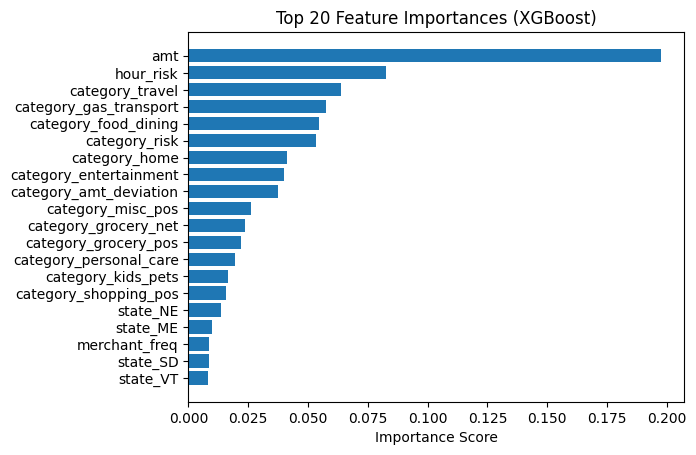

In [ ]:
# Built-in XGBoost Feature Importance
import matplotlib.pyplot as plt

feature_names = X_full_encoded.columns

importances = final_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Top 20 features
top_features = importance_df.head(20)

plt.figure()
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

The feature importance plot highlights the most influential variables driving fraud predictions. Transaction amount (amt) emerges as the strongest predictor, significantly outweighing other features. This suggests that higher-value transactions are more likely to be associated with fraudulent activity.

Risk-encoded features such as hour_risk, category_risk, and merchant_risk also rank highly, confirming that historical fraud patterns within specific time periods and transaction categories provide strong predictive signal.

Importantly, engineered features such as category_amt_deviation contribute meaningfully to the model, indicating that abnormal spending behavior relative to category norms is a key fraud indicator.

Overall, the importance rankings validate the effectiveness of the feature engineering strategy.

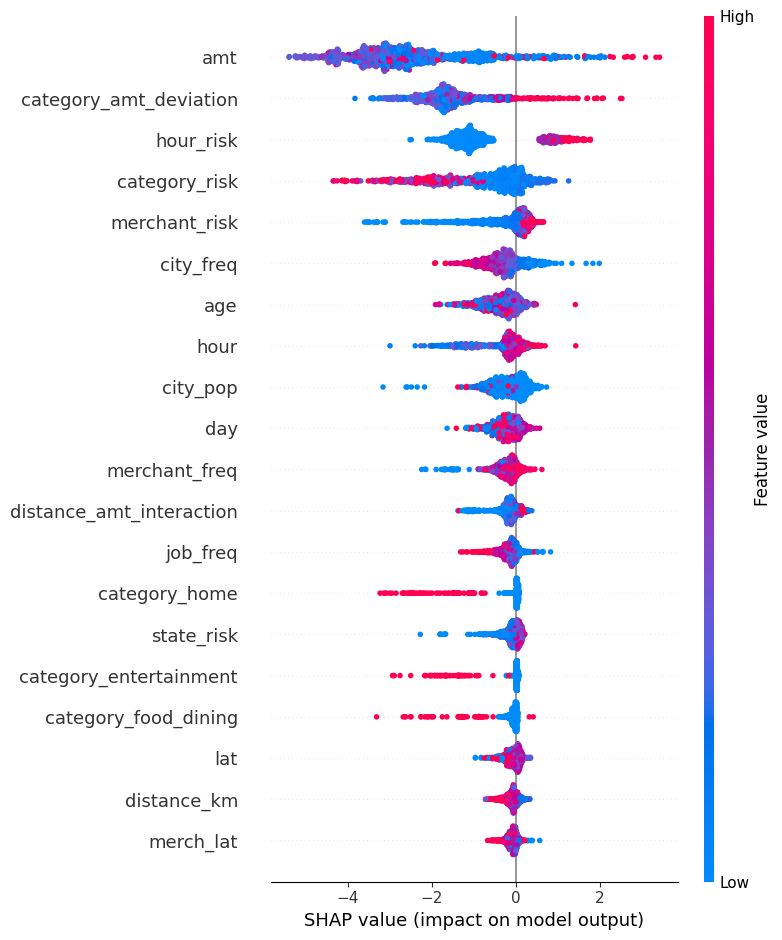

In [ ]:
import shap

import shap
import numpy as np

# Sample 1000 rows from test data
sample_size = 1000
sample_idx = np.random.choice(len(X_test_encoded), sample_size, replace=False)

X_sample = X_test_encoded.iloc[sample_idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

The SHAP summary plot provides a global explanation of how features influence fraud predictions. Each dot represents a transaction, with color indicating feature value (red = high, blue = low), and horizontal position showing impact on fraud probability.

According to that, high transaction amounts strongly push predictions toward fraud, while low amounts push predictions toward legitimate outcomes. Similarly, large deviations from typical category spending increase fraud likelihood.

Risk-encoded variables such as hour_risk, category_risk, and merchant_risk consistently shift predictions toward fraud when their values are high. This confirms that the model is capturing behavioral and temporal risk patterns rather than relying solely on raw transaction attributes.

The model’s decisions are therefore aligned with logical fraud behavior patterns.

In [ ]:

import shap
import numpy as np

shap.initjs()

# Sample test data
sample_size = 1000
sample_idx = np.random.choice(len(X_test_encoded), sample_size, replace=False)

X_sample = X_test_encoded.iloc[sample_idx]

# Compute SHAP values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_sample)

# Predict fraud with business threshold
sample_predictions = (
    final_model.predict_proba(X_sample)[:, 1] >= 0.75
).astype(int)

fraud_indices = np.where(sample_predictions == 1)[0]

if len(fraud_indices) == 0:
    print("No fraud cases found in sample — increase sample size.")
else:
    for idx in fraud_indices[:3]:
        display(shap.force_plot(
            explainer.expected_value,
            shap_values.values[idx],
            X_sample.iloc[idx]
        ))

The SHAP force plots illustrate how the model arrives at a fraud prediction for specific transactions. The baseline value represents the average fraud risk in the dataset, while each feature either increases (red) or decreases (blue) the predicted probability.

In the first example, the prediction is driven upward primarily by a high transaction amount, large deviation from typical category spending, and elevated hour-based risk. These strong red contributions outweigh the smaller blue factors, leading to a high fraud score.

The second example shows a similar pattern, where abnormal spending behavior and higher-risk temporal signals push the model toward fraud despite some stabilizing features.

The third transaction presents a lower transaction amount, but risk-related signals such as merchant and hour risk still increase the fraud likelihood. However, multiple legitimate indicators counterbalance these effects, resulting in a comparatively lower fraud score.

Overall, these explanations demonstrate that the model bases its decisions on intuitive behavioral risk signals rather than arbitrary correlations, supporting interpretability and operational transparency.

In [ ]:
#Financial impact calculation
avg_fraud_loss = 200
investigation_cost = 5

total_transactions = len(y_test)
total_fraud = tp + fn

fraud_caught = tp
alerts_generated = tp + fp

fraud_saved = tp * avg_fraud_loss
investigation_expense = alerts_generated * investigation_cost
missed_fraud_loss = fn * avg_fraud_loss

net_savings = fraud_saved - investigation_expense

fraud_rate = total_fraud / total_transactions
catch_rate = tp / (tp + fn)
precision = tp / (tp + fp)
alerts_per_100k = (alerts_generated / total_transactions) * 100000
roi = net_savings / investigation_expense if investigation_expense > 0 else 0

print("\n===== FINANCIAL IMPACT (TEST DATA) =====")
print(f"Fraud Rate: {fraud_rate:.2%}")
print(f"Fraud Catch Rate: {catch_rate:.2%}")
print(f"Alert Precision: {precision:.2%}")
print(f"Alerts per 100k Transactions: {alerts_per_100k:.0f}")
print(f"Fraud Dollars Saved: ${fraud_saved:,.0f}")
print(f"Investigation Cost: ${investigation_expense:,.0f}")
print(f"Missed Fraud Loss: ${missed_fraud_loss:,.0f}")
print(f"Net Savings: ${net_savings:,.0f}")
print(f"ROI (Savings per $1 Investigated): {roi:.2f}x")


===== FINANCIAL IMPACT (TEST DATA) =====
Fraud Rate: 0.39%
Fraud Catch Rate: 84.71%
Alert Precision: 58.54%
Alerts per 100k Transactions: 559
Fraud Dollars Saved: $363,400
Investigation Cost: $15,520
Missed Fraud Loss: $65,600
Net Savings: $347,880
ROI (Savings per $1 Investigated): 22.41x


The financial impact evaluation translates model performance into business outcomes. On the test dataset, the model achieved:

* Fraud detection rate: 84.7%

* Alert precision: 58.5%

* Net savings: $347,880

* Return on investment (ROI): 22.4x

This indicates that for every dollar spent on investigation, approximately $22 is saved in prevented fraud losses. The model therefore not only performs well statistically but also delivers substantial financial value.

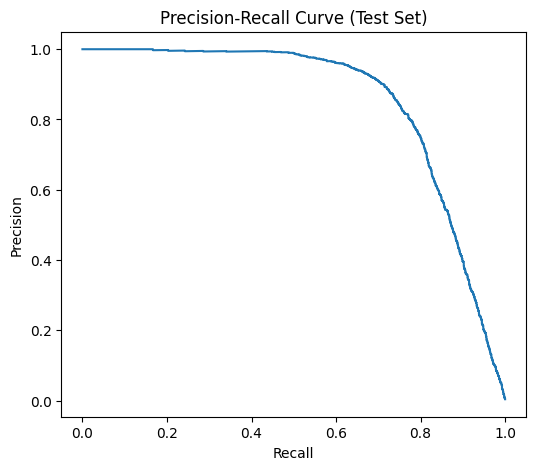

In [ ]:
# PRECISION RECALL CURVE

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, test_proba)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Test Set)")
plt.show()

The precision–recall curve illustrates the trade-off between fraud detection rate (recall) and alert quality (precision) across different thresholds.

At lower recall levels, precision remains very high, indicating that conservative thresholds yield highly accurate fraud alerts. As recall increases, precision gradually declines, reflecting the natural trade-off between catching more fraud and increasing false positives.

The curve demonstrates strong ranking performance, with high precision maintained across a broad range of recall values. This confirms that threshold tuning can be used strategically to balance operational workload and fraud prevention goals.

# **6.0 CONCLUSION**
This project developed an end-to-end machine learning pipeline for credit card fraud detection using a highly imbalanced transactional dataset. The workflow covered data understanding, exploratory analysis, feature engineering, imbalance handling, model comparison, hyperparameter tuning, and final evaluation on unseen test data.

Feature engineering played a critical role in improving performance. Behavioral features such as risk encoding, transaction amount deviation, and interaction variables significantly enhanced predictive power. Model comparison using stratified cross-validation and PR-AUC as the primary metric ensured a fair and robust evaluation process in the presence of severe class imbalance.

The final tuned XGBoost model achieved strong performance on the test dataset, with a PR-AUC of 0.85 and a fraud detection rate of approximately 85%. The model maintained a reasonable precision level, effectively balancing fraud detection and false alerts. Financial impact analysis further demonstrated that the system delivers substantial business value, generating significant net savings and a high return on investigation cost.

SHAP-based interpretability confirmed that the model’s predictions are driven by meaningful behavioral patterns such as high transaction amounts, abnormal spending deviations, and elevated temporal risk signals. This enhances transparency and supports real-world deployment considerations.

Overall, the solution demonstrates not only strong statistical performance but also operational feasibility, financial viability, and interpretability — all critical components of a production-ready fraud detection system.

# **7.0 REFERENCE:**

1. Bahnsen, A. C., Aouada, D., Stojanovic, A., & Ottersten, B. (2016). Feature engineering strategies for credit card fraud detection. Expert Systems with Applications, 51, 134–142.

2. Bhattacharyya, S., Jha, S., Tharakunnel, K., & Westland, J. C. (2011). Data mining for credit card fraud: A comparative study. Decision Support Systems, 50(3), 602–613.

3. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. Journal of Artificial Intelligence Research, 16, 321–357.

4. Dal Pozzolo, A., Boracchi, G., Caelen, O., Alippi, C., & Bontempi, G. (2015). Credit card fraud detection: A realistic modeling and a new public dataset. Proceedings of the IEEE Symposium on Computational Intelligence and Data Mining, 245–252.

5. Elkan, C. (2001). The foundations of cost-sensitive learning. Proceedings of the 17th International Joint Conference on Artificial Intelligence (IJCAI), 973–978.

6. Fawcett, T. (2006). An introduction to ROC analysis. Pattern Recognition Letters, 27(8), 861–874.

7. Federal Trade Commission. (2023). Consumer Sentinel Network data book 2023. Federal Trade Commission.

8. Hastie, T., Tibshirani, R., & Friedman, J. (2009). The elements of statistical learning: Data mining, inference, and prediction (2nd ed.). Springer.

9.  He, H., & Garcia, E. A. (2009). Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284.

10. Japkowicz, N., & Stephen, S. (2002). The class imbalance problem: A systematic study. Intelligent Data Analysis, 6(5), 429–449.

11. Jurgovsky, J., Granitzer, M., Ziegler, K., Calabretto, S., Portier, P. E., He-Guelton, L., & Caelen, O. (2018). Sequence classification for credit-card fraud detection. Expert Systems with Applications, 100, 234–245.

12. Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. Proceedings of the 14th International Joint Conference on Artificial Intelligence (IJCAI), 1137–1145.

13. Kuhn, M., & Johnson, K. (2013). Applied predictive modeling. Springer.

14. Micci-Barreca, D. (2001). A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems. ACM SIGKDD Explorations Newsletter, 3(1), 27–32.

15. Nilson Report. (2022). Global card fraud losses reach $32.34 billion. The Nilson Report.

16. Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to ROC, informedness, markedness & correlation. Journal of Machine Learning Technologies, 2(1), 37–63.

17. PwC. (2022). Global economic crime and fraud survey 2022. PricewaterhouseCoopers.

18. Saito, T., & Rehmsmeier, M. (2015). The precision–recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. PLoS ONE, 10(3), e0118432.

19. UK Finance. (2023). Fraud the facts 2023. UK Finance.